# quantitative-derivative-pricing

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

In [1]:
import numpy as np
import pandas as pd

### ==========================================
### CLASS: Binomial Tree Option Pricer
### ==========================================

In [2]:
class BinomialTreePricer:
    def __init__(self, S0, K, r, T, sigma, N, option_type='C', american=False):
        self.S0 = S0
        self.K = K
        self.r = r
        self.T = T
        self.sigma = sigma
        self.N = int(N)
        self.option_type = option_type  # 'C' for Call, 'P' for Put
        self.american = american        # True for American, False for European
        self.dt = T / N
        self.df = np.exp(-r * self.dt)  # Discount factor per step

        # CRR (Cox-Ross-Rubinstein) Parameters
        self.u = np.exp(sigma * np.sqrt(self.dt))
        self.d = 1 / self.u
        self.p = (np.exp(r * self.dt) - self.d) / (self.u - self.d)

    def price(self):
        # Initialize asset prices at maturity (Step N)
        # S_T = S0 * u^j * d^(N-j)
        asset_prices = self.S0 * (self.u ** np.arange(self.N, -1, -1)) * (self.d ** np.arange(0, self.N + 1, 1))
        
        # Initialize option values at maturity
        if self.option_type == 'C':
            values = np.maximum(asset_prices - self.K, 0)
        else:
            values = np.maximum(self.K - asset_prices, 0)

        # Backward induction
        for i in range(self.N - 1, -1, -1):
            # Option value if held (continuation value)
            val_hold = self.df * (self.p * values[:-1] + (1 - self.p) * values[1:])
            
            # Asset prices at step i
            S_t = self.S0 * (self.u ** np.arange(i, -1, -1)) * (self.d ** np.arange(0, i + 1, 1))
            
            if self.american:
                # Value if exercised immediately (intrinsic value)
                if self.option_type == 'C':
                    val_exercise = np.maximum(S_t - self.K, 0)
                else:
                    val_exercise = np.maximum(self.K - S_t, 0)
                values = np.maximum(val_hold, val_exercise)
            else:
                values = val_hold
        
        self.option_price = values[0]
        return self.option_price

    def get_delta(self):
        # We need values at nodes (1,0) [up] and (1,1) [down] to calculate Delta at t=0
        # Re-calculate simple 1-step move from t=1 to t=0
        
        # Recalculate full tree to get the values at step 1
        asset_prices = self.S0 * (self.u ** np.arange(self.N, -1, -1)) * (self.d ** np.arange(0, self.N + 1, 1))
        
        if self.option_type == 'C':
            values = np.maximum(asset_prices - self.K, 0)
        else:
            values = np.maximum(self.K - asset_prices, 0)

        for i in range(self.N - 1, 0, -1): # Stop at i=1
            val_hold = self.df * (self.p * values[:-1] + (1 - self.p) * values[1:])
            S_t = self.S0 * (self.u ** np.arange(i, -1, -1)) * (self.d ** np.arange(0, i + 1, 1))
            if self.american:
                if self.option_type == 'C': val_exercise = np.maximum(S_t - self.K, 0)
                else: val_exercise = np.maximum(self.K - S_t, 0)
                values = np.maximum(val_hold, val_exercise)
            else:
                values = val_hold
        
        # Now 'values' contains option values at step 1: [V_u, V_d]
        V_u = values[0]
        V_d = values[1]
        S_u = self.S0 * self.u
        S_d = self.S0 * self.d
        
        delta = (V_u - V_d) / (S_u - S_d)
        return delta

### ==========================================
### MAIN EXECUTION (Step 1)
### ==========================================

In [3]:
def run_step_1():
    print("--- STEP 1 OUTPUT: BINOMIAL TREES ---")
    
    # Parameters given in project
    S0 = 100
    K = 100  # ATM
    r = 0.05
    sigma = 0.20
    T = 3/12 # 3 months
    N = 200  # Number of steps (Chosen for high convergence accuracy)

    print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, T={T}, N={N}\n")

    # ---------------------------------------------------
    # TEAM MEMBER A: European Options
    # ---------------------------------------------------
    print("--- Q5 & Q6: European Options (Price & Delta) ---")
    eur_call = BinomialTreePricer(S0, K, r, T, sigma, N, 'C', american=False)
    eur_put = BinomialTreePricer(S0, K, r, T, sigma, N, 'P', american=False)
    
    p_eur_c = eur_call.price()
    d_eur_c = eur_call.get_delta()
    p_eur_p = eur_put.price()
    d_eur_p = eur_put.get_delta()
    
    print(f"European Call Price: {p_eur_c:.4f} | Delta: {d_eur_c:.4f}")
    print(f"European Put Price:  {p_eur_p:.4f} | Delta: {d_eur_p:.4f}")
    print("-" * 30)

    # ---------------------------------------------------
    # Q7: Vega (Sensitivity to Volatility)
    # ---------------------------------------------------
    print("\n--- Q7: Vega (Sensitivity to Sigma increase to 25%) ---")
    sigma_new = 0.25
    
    eur_call_v = BinomialTreePricer(S0, K, r, T, sigma_new, N, 'C', american=False)
    eur_put_v = BinomialTreePricer(S0, K, r, T, sigma_new, N, 'P', american=False)
    
    p_eur_c_v = eur_call_v.price()
    p_eur_p_v = eur_put_v.price()
    
    print(f"New Sigma: {sigma_new*100}%")
    print(f"Eur Call (New): {p_eur_c_v:.4f} | Change (Vega Impact): {p_eur_c_v - p_eur_c:.4f}")
    print(f"Eur Put (New):  {p_eur_p_v:.4f} | Change (Vega Impact): {p_eur_p_v - p_eur_p:.4f}")
    print("-" * 30)

    # ---------------------------------------------------
    # TEAM MEMBER B: American Options
    # ---------------------------------------------------
    print("\n--- Q8 & Q9: American Options (Price & Delta) ---")
    am_call = BinomialTreePricer(S0, K, r, T, sigma, N, 'C', american=True)
    am_put = BinomialTreePricer(S0, K, r, T, sigma, N, 'P', american=True)
    
    p_am_c = am_call.price()
    d_am_c = am_call.get_delta()
    p_am_p = am_put.price()
    d_am_p = am_put.get_delta()
    
    print(f"American Call Price: {p_am_c:.4f} | Delta: {d_am_c:.4f}")
    print(f"American Put Price:  {p_am_p:.4f} | Delta: {d_am_p:.4f}")
    print("-" * 30)

    # ---------------------------------------------------
    # Q10: Vega for American Options
    # ---------------------------------------------------
    print("\n--- Q10: American Vega (Sigma 20% -> 25%) ---")
    am_call_v = BinomialTreePricer(S0, K, r, T, sigma_new, N, 'C', american=True)
    am_put_v = BinomialTreePricer(S0, K, r, T, sigma_new, N, 'P', american=True)
    
    p_am_c_v = am_call_v.price()
    p_am_p_v = am_put_v.price()
    
    print(f"Am Call (New): {p_am_c_v:.4f} | Change (Vega Impact): {p_am_c_v - p_am_c:.4f}")
    print(f"Am Put (New):  {p_am_p_v:.4f} | Change (Vega Impact): {p_am_p_v - p_am_p:.4f}")
    print("-" * 30)

    # ---------------------------------------------------
    # TEAM MEMBER C: Confirmations & Parity Checks
    # ---------------------------------------------------
    print("\n--- Q11-Q14: Confirmations & Parity Checks ---")
    
    # Q11: European Parity: C + Ke^(-rT) = P + S0
    lhs_eur = p_eur_c + K * np.exp(-r * T)
    rhs_eur = p_eur_p + S0
    diff_eur = lhs_eur - rhs_eur
    print(f"Q11 Eur Parity Check:")
    print(f"   C + PV(K) = {lhs_eur:.4f}")
    print(f"   P + S0    = {rhs_eur:.4f}")
    print(f"   Diff      = {diff_eur:.6f} (Should be ~0)")

    # Q12: American Parity Check (S0 - K <= C - P <= S0 - PV(K))
    diff_am = p_am_c - p_am_p
    lower_bound = S0 - K
    upper_bound = S0 - K * np.exp(-r * T)
    
    print(f"\nQ12 American Parity Check:")
    print(f"   C - P = {diff_am:.4f}")
    print(f"   Lower Bound (S0 - K) = {lower_bound:.4f}")
    print(f"   Upper Bound (S0 - PV(K)) = {upper_bound:.4f}")
    
    # Use round() to avoid floating point floating issues
    is_valid = (round(lower_bound, 4) <= round(diff_am, 4)) and (round(diff_am, 4) <= round(upper_bound, 4))
    print(f"   Holds? {is_valid}")

    # Q13 & Q14: Comparison
    print(f"\nQ13: Eur Call ({p_eur_c:.4f}) <= Am Call ({p_am_c:.4f})? {p_eur_c <= p_am_c}")
    print(f"Q14: Eur Put  ({p_eur_p:.4f}) <= Am Put  ({p_am_p:.4f})? {p_eur_p <= p_am_p}")

if __name__ == "__main__":
    run_step_1()

--- STEP 1 OUTPUT: BINOMIAL TREES ---
Parameters: S0=100, K=100, r=0.05, sigma=0.2, T=0.25, N=200

--- Q5 & Q6: European Options (Price & Delta) ---
European Call Price: 4.6100 | Delta: 0.5694
European Put Price:  3.3678 | Delta: -0.4306
------------------------------

--- Q7: Vega (Sensitivity to Sigma increase to 25%) ---
New Sigma: 25.0%
Eur Call (New): 5.5922 | Change (Vega Impact): 0.9822
Eur Put (New):  4.3500 | Change (Vega Impact): 0.9822
------------------------------

--- Q8 & Q9: American Options (Price & Delta) ---
American Call Price: 4.6100 | Delta: 0.5694
American Put Price:  3.4772 | Delta: -0.4496
------------------------------

--- Q10: American Vega (Sigma 20% -> 25%) ---
Am Call (New): 5.5922 | Change (Vega Impact): 0.9822
Am Put (New):  4.4564 | Change (Vega Impact): 0.9792
------------------------------

--- Q11-Q14: Confirmations & Parity Checks ---
Q11 Eur Parity Check:
   C + PV(K) = 103.3678
   P + S0    = 103.3678
   Diff      = 0.000000 (Should be ~0)

Q12 A

In [4]:
import matplotlib.pyplot as plt

### ==========================================
### CLASS: Trinomial Tree Option Pricer
### ==========================================

In [5]:
class TrinomialTreePricer:
    def __init__(self, S0, K, r, T, sigma, N, option_type='C', american=False):
        self.S0 = S0
        self.K = K
        self.r = r
        self.T = T
        self.sigma = sigma
        self.N = int(N)
        self.option_type = option_type
        self.american = american
        self.dt = T / N
        self.df = np.exp(-r * self.dt)

        # Trinomial Parameters (Standard implementation)
        # u = exp(sigma * sqrt(2*dt)), d = 1/u, m = 1
        # To ensure stability, we use standard approximations:
        self.dx = sigma * np.sqrt(2 * self.dt)
        self.u = np.exp(self.dx)
        self.d = 1 / self.u
        self.m = 1.0 # Middle path stays same (in log space approx) -> actually e^0 = 1

        # Probabilities
        # pu = ((e^(r*dt/2) - e^(-sigma*sqrt(dt/2))) / (e^(sigma*sqrt(dt/2)) - e^(-sigma*sqrt(dt/2))))^2
        # A clearer standard approximation for Trinomial trees:
        # pu = ( (e^(r*dt) - d) - (m - d) ) / (u - d) ... simpler versions exist.
        # Let's use the standard "optimal" probabilities for convergence:
        
        # Intermediate terms
        drift = r - 0.5 * sigma**2
        
        # Probabilities (approximate for stability)
        self.pu = 0.5 * ((sigma**2 * self.dt + (drift * self.dt)**2) / (self.dx**2) + (drift * self.dt) / self.dx)
        self.pd = 0.5 * ((sigma**2 * self.dt + (drift * self.dt)**2) / (self.dx**2) - (drift * self.dt) / self.dx)
        self.pm = 1 - self.pu - self.pd

    def price(self):
        # Initialize asset prices at maturity
        # Nodes range from +N to -N
        # S_j = S0 * u^j where j is in [-N, ..., 0, ..., N]
        
        # More efficient: Just compute the leaf nodes
        indices = np.arange(self.N, -self.N - 1, -1)
        asset_prices = self.S0 * (self.u ** indices)
        
        # Initialize Option Values at Maturity
        if self.option_type == 'C':
            values = np.maximum(asset_prices - self.K, 0)
        else:
            values = np.maximum(self.K - asset_prices, 0)

        # Backward Induction
        for i in range(self.N - 1, -1, -1):
            # Because it's trinomial, values[j] depends on values[j+1] (up), values[j] (mid), values[j-1] (down)
            # The 'values' array size shrinks by 2 each step if we trim edges, or we map indices.
            # To vectorize: 
            # val_up = values[0:-2]
            # val_mid = values[1:-1]
            # val_down = values[2:]
            
            val_hold = self.df * (self.pu * values[:-2] + self.pm * values[1:-1] + self.pd * values[2:])
            
            # Asset prices at step i
            # Indices range from +i to -i
            indices_i = np.arange(i, -i - 1, -1)
            S_t = self.S0 * (self.u ** indices_i)
            
            if self.american:
                if self.option_type == 'C':
                    val_exercise = np.maximum(S_t - self.K, 0)
                else:
                    val_exercise = np.maximum(self.K - S_t, 0)
                values = np.maximum(val_hold, val_exercise)
            else:
                values = val_hold
                
        return values[0]

### ==========================================
### MAIN EXECUTION (Step 2)
### ==========================================

--- STEP 2 OUTPUT: TRINOMIAL TREES & GRAPHS ---

Pricing for Strikes: [90.0, 95.0, 100.0, 105.0, 110.00000000000001] (S0=100)

--- Pricing Results Table (Q15-18) ---
    Strike  Moneyness  Eur_Call  Eur_Put  Am_Call  Am_Put  Parity_Diff
0  90.0000     0.9000   11.6717   0.5537  11.6717  0.5643      -0.0000
1  95.0000     0.9500    7.7176   1.5376   7.7176  1.5755      -0.0000
2 100.0000     1.0000    4.6101   3.3679   4.6101  3.4762      -0.0000
3 105.0000     1.0500    2.4819   6.1776   2.4819  6.4261      -0.0000
4 110.0000     1.1000    1.1918   9.8254   1.1918 10.3299      -0.0000


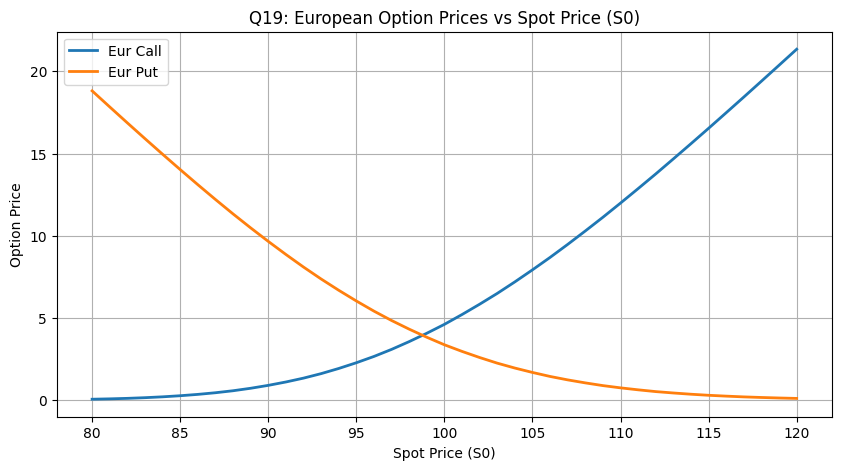

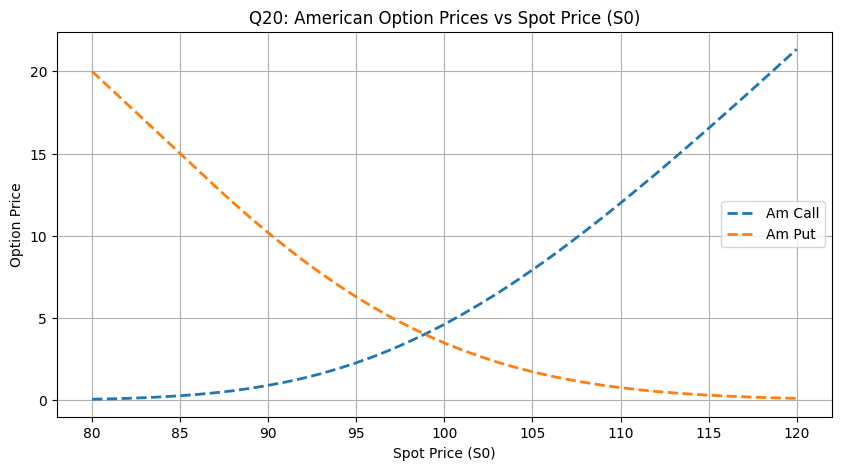

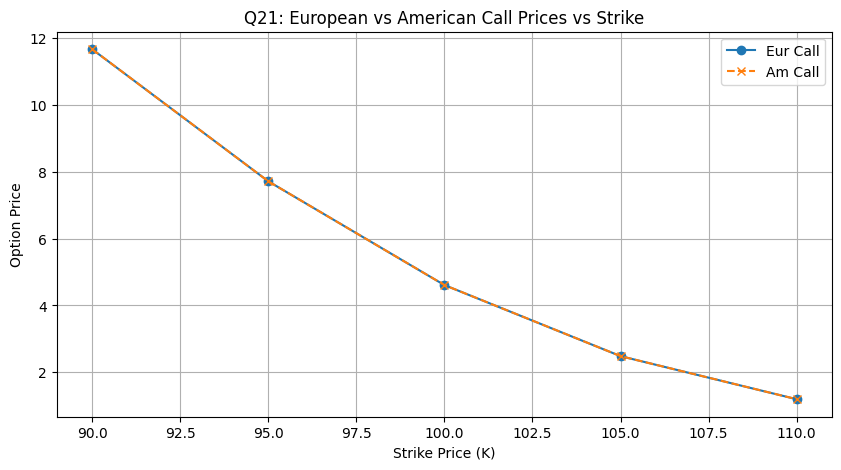

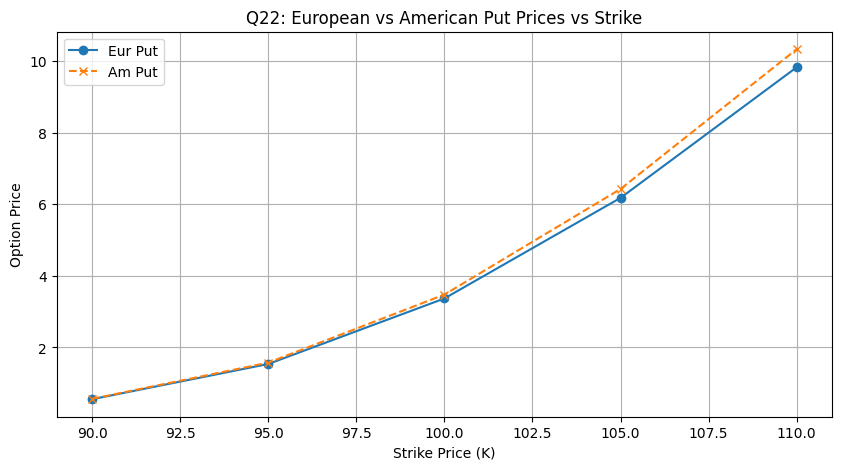

In [7]:
def run_step_2():
    print("--- STEP 2 OUTPUT: TRINOMIAL TREES & GRAPHS ---")
    
    S0 = 100
    r = 0.05
    sigma = 0.20
    T = 0.25 # 3 months
    N = 100  # Trinomial converges faster, N=100 is solid
    
    # --------------------------------------------------------
    # Q15-18: Price 5 Strikes (Deep OTM -> Deep ITM)
    # --------------------------------------------------------
    # Moneyness = K/S0. 
    # Strikes: 90, 95, 100, 105, 110
    moneyness_levels = [0.90, 0.95, 1.00, 1.05, 1.10]
    strikes = [m * S0 for m in moneyness_levels]
    
    results = []
    
    print(f"\nPricing for Strikes: {strikes} (S0={S0})")
    
    for K in strikes:
        # European
        eur_call = TrinomialTreePricer(S0, K, r, T, sigma, N, 'C', False).price()
        eur_put = TrinomialTreePricer(S0, K, r, T, sigma, N, 'P', False).price()
        
        # American
        am_call = TrinomialTreePricer(S0, K, r, T, sigma, N, 'C', True).price()
        am_put = TrinomialTreePricer(S0, K, r, T, sigma, N, 'P', True).price()
        
        # Parity Check (European): C + PV(K) - (P + S0)
        parity_diff = (eur_call + K * np.exp(-r*T)) - (eur_put + S0)
        
        results.append({
            "Strike": K,
            "Moneyness": K/S0,
            "Eur_Call": eur_call,
            "Eur_Put": eur_put,
            "Am_Call": am_call,
            "Am_Put": am_put,
            "Parity_Diff": parity_diff
        })
    
    df_res = pd.DataFrame(results)
    print("\n--- Pricing Results Table (Q15-18) ---")
    print(df_res.to_string(float_format="%.4f"))

    # --------------------------------------------------------
    # GRAPHS (Q19-Q22)
    # --------------------------------------------------------
    # To graph Price vs S0, we need a range of Stock Prices
    S_range = np.linspace(80, 120, 41)
    K_fixed = 100
    
    ec_prices = []
    ep_prices = []
    ac_prices = []
    ap_prices = []
    
    for s in S_range:
        ec_prices.append(TrinomialTreePricer(s, K_fixed, r, T, sigma, N, 'C', False).price())
        ep_prices.append(TrinomialTreePricer(s, K_fixed, r, T, sigma, N, 'P', False).price())
        ac_prices.append(TrinomialTreePricer(s, K_fixed, r, T, sigma, N, 'C', True).price())
        ap_prices.append(TrinomialTreePricer(s, K_fixed, r, T, sigma, N, 'P', True).price())

    # GRAPH 1: Eur Call/Put vs Stock Price
    plt.figure(figsize=(10, 5))
    plt.plot(S_range, ec_prices, label='Eur Call', linewidth=2)
    plt.plot(S_range, ep_prices, label='Eur Put', linewidth=2)
    plt.title('Q19: European Option Prices vs Spot Price (S0)')
    plt.xlabel('Spot Price (S0)')
    plt.ylabel('Option Price')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # GRAPH 2: Am Call/Put vs Stock Price
    plt.figure(figsize=(10, 5))
    plt.plot(S_range, ac_prices, label='Am Call', linewidth=2, linestyle='--')
    plt.plot(S_range, ap_prices, label='Am Put', linewidth=2, linestyle='--')
    plt.title('Q20: American Option Prices vs Spot Price (S0)')
    plt.xlabel('Spot Price (S0)')
    plt.ylabel('Option Price')
    plt.legend()
    plt.grid(True)
    plt.show()

    # GRAPH 3: Eur vs Am Call vs Strike (Using previous DF)
    plt.figure(figsize=(10, 5))
    plt.plot(df_res['Strike'], df_res['Eur_Call'], label='Eur Call', marker='o')
    plt.plot(df_res['Strike'], df_res['Am_Call'], label='Am Call', marker='x', linestyle='--')
    plt.title('Q21: European vs American Call Prices vs Strike')
    plt.xlabel('Strike Price (K)')
    plt.ylabel('Option Price')
    plt.legend()
    plt.grid(True)
    plt.show()

    # GRAPH 4: Eur vs Am Put vs Strike
    plt.figure(figsize=(10, 5))
    plt.plot(df_res['Strike'], df_res['Eur_Put'], label='Eur Put', marker='o')
    plt.plot(df_res['Strike'], df_res['Am_Put'], label='Am Put', marker='x', linestyle='--')
    plt.title('Q22: European vs American Put Prices vs Strike')
    plt.xlabel('Strike Price (K)')
    plt.ylabel('Option Price')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    run_step_2()

### ==========================================
### PART 1: BINOMIAL HEDGING (European & American)
### ==========================================

In [11]:
class BinomialHedgingEngine:
    def __init__(self, S0, K, r, T, sigma, N, option_type='P', american=False):
        self.S0 = S0
        self.K = K
        self.r = r
        self.T = T
        self.sigma = sigma
        self.N = N
        self.option_type = option_type
        self.american = american
        self.dt = T / N
        self.df = np.exp(-r * self.dt)
        self.u = np.exp(sigma * np.sqrt(self.dt))
        self.d = 1 / self.u
        self.p = (np.exp(r * self.dt) - self.d) / (self.u - self.d)

    def run_hedging_simulation(self):
        # 1. Build the Tree (Price & Delta)
        # We need to store S and Option Value at every node to calculate Delta later
        
        # Grid initialization
        # tree_v[i][j] is option value at step i, node j
        # tree_s[i][j] is stock price at step i, node j
        tree_v = [np.zeros(i+1) for i in range(self.N + 1)]
        tree_s = [np.zeros(i+1) for i in range(self.N + 1)]
        
        # Populate Stock Prices
        for i in range(self.N + 1):
            for j in range(i + 1):
                tree_s[i][j] = self.S0 * (self.u ** (i - j)) * (self.d ** j)
                
        # Populate Option Values (Backward)
        # Terminal Payoff
        for j in range(self.N + 1):
            if self.option_type == 'C':
                tree_v[self.N][j] = np.maximum(tree_s[self.N][j] - self.K, 0)
            else:
                tree_v[self.N][j] = np.maximum(self.K - tree_s[self.N][j], 0)
                
        # Backward Induction
        for i in range(self.N - 1, -1, -1):
            for j in range(i + 1):
                hold = self.df * (self.p * tree_v[i+1][j] + (1 - self.p) * tree_v[i+1][j+1])
                if self.american:
                    if self.option_type == 'C': intrinsic = max(tree_s[i][j] - self.K, 0)
                    else: intrinsic = max(self.K - tree_s[i][j], 0)
                    tree_v[i][j] = max(hold, intrinsic)
                else:
                    tree_v[i][j] = hold

        # 2. Simulate One Path (Down-Down-Down... or random)
        # Let's pick a specific path: Alternating Down, Up, Down, Up... to see hedging action
        # Or specifically Down-Down-Down for a Put to trigger action.
        # Let's randomize it for realism, but fix seed for reproducibility.
        np.random.seed(42)
        
        path_indices = [0] # Start at node 0
        path_s = [self.S0]
        
        current_node_idx = 0
        for i in range(1, self.N + 1):
            # Random move
            if np.random.rand() > 0.5:
                # Up (index stays same in my notation: u is index 0, d is index 1? No.)
                # In my loop above: S = u^(i-j) * d^j.
                # So index j=0 is max Up. j increases -> Down move.
                # Let's say Up move -> j stays same. Down move -> j increases by 1.
                move = 'UP'
            else:
                move = 'DOWN'
                current_node_idx += 1
            
            path_indices.append(current_node_idx)
            path_s.append(tree_s[i][current_node_idx])

        # 3. Calculate Cash Account Evolution
        # We sell the Option at t=0. Cash = +OptionPrice
        # We need to Delta Hedge.
        # Delta = (V_up - V_down) / (S_up - S_down)
        
        results = []
        cash_balance = tree_v[0][0] # Received premium
        shares_held = 0
        
        for i in range(self.N):
            # Current State
            node_idx = path_indices[i]
            S_curr = tree_s[i][node_idx]
            
            # Calculate Delta at this node
            # Look ahead to i+1 nodes
            S_up = tree_s[i+1][node_idx]
            S_down = tree_s[i+1][node_idx+1]
            V_up = tree_v[i+1][node_idx]
            V_down = tree_v[i+1][node_idx+1]
            
            delta = (V_up - V_down) / (S_up - S_down)
            
            # Rebalancing
            # We need to hold 'delta' shares.
            # For a Put, delta is negative (e.g., -0.4). We Short Sell 0.4 shares.
            # If we already hold shares, we adjust.
            
            shares_needed = delta
            shares_to_buy = shares_needed - shares_held
            
            cost = shares_to_buy * S_curr
            
            # Update Cash (Interest accrues on previous balance)
            if i > 0:
                # Add interest for one period
                cash_balance = cash_balance * np.exp(self.r * self.dt)
            
            cash_balance -= cost
            shares_held = shares_needed
            
            results.append({
                "Step": i,
                "S_t": S_curr,
                "Option_Val": tree_v[i][node_idx],
                "Delta": delta,
                "Shares_Held": shares_held,
                "Cash_Cost": cost,
                "Cash_Acct": cash_balance
            })
            
        # Final Step (Liquidation)
        i = self.N
        node_idx = path_indices[i]
        S_final = tree_s[i][node_idx]
        
        # Add interest to final step
        cash_balance = cash_balance * np.exp(self.r * self.dt)
        
        # Close Short Position (Buy back shares)
        cost_close = -shares_held * S_final
        cash_balance -= cost_close
        shares_held = 0
        
        # Payoff Liability (We sold the put, we owe the payoff)
        payoff = tree_v[self.N][node_idx]
        cash_balance -= payoff
        
        results.append({
            "Step": i,
            "S_t": S_final,
            "Option_Val": payoff,
            "Delta": 0,
            "Shares_Held": 0,
            "Cash_Cost": cost_close,
            "Cash_Acct": cash_balance # This is the PnL (should be small/zero)
        })
        
        return pd.DataFrame(results)

### ==========================================
### PART 2: ASIAN OPTION (Monte Carlo)
### ==========================================

In [12]:
def price_asian_put_mc(S0, K, r, T, sigma, num_sims=10000, num_steps=100):
    np.random.seed(42)
    dt = T / num_steps
    
    # Simulate Paths
    # S_t = S0 * exp( (r - 0.5*sigma^2)*t + sigma*sqrt(t)*Z )
    Z = np.random.standard_normal((num_sims, num_steps))
    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)
    
    # Log returns
    log_rets = drift + vol * Z
    log_paths = np.cumsum(log_rets, axis=1)
    
    # S paths (add S0)
    paths = S0 * np.exp(np.hstack((np.zeros((num_sims, 1)), log_paths)))
    
    # Asian Payoff: Max(K - Average(S), 0)
    # Average can be Arithmetic Mean
    avg_prices = np.mean(paths, axis=1)
    payoffs = np.maximum(K - avg_prices, 0)
    
    # Discount
    price = np.exp(-r * T) * np.mean(payoffs)
    return price

### ==========================================
### MAIN EXECUTION (Step 3)
### ==========================================

In [13]:
def run_step_3():
    print("--- STEP 3: DYNAMIC HEDGING & REAL WORLD ---")
    
    # Data from Q25
    S0 = 180
    K = 182
    r = 0.02
    sigma = 0.25
    T = 6/12 # 0.5 years
    
    # -----------------------------------------------
    # Q25: European Put Hedging (3 Steps)
    # -----------------------------------------------
    print("\n--- Q25: European Put Hedging (3 Steps) ---")
    N_small = 3
    engine_eur = BinomialHedgingEngine(S0, K, r, T, sigma, N_small, 'P', False)
    df_eur = engine_eur.run_hedging_simulation()
    
    print("Hedging Table (European, N=3, One Path):")
    print(df_eur.to_string(float_format="%.4f"))
    print(f"Final PnL (Hedging Error): {df_eur.iloc[-1]['Cash_Acct']:.4f}")

    # -----------------------------------------------
    # Q26: American Put Hedging (25 Steps)
    # -----------------------------------------------
    print("\n--- Q26: American Put Hedging (25 Steps) ---")
    N_large = 25
    engine_am = BinomialHedgingEngine(S0, K, r, T, sigma, N_large, 'P', True)
    df_am = engine_am.run_hedging_simulation()
    
    # Print first few and last few rows to save space
    print("Hedging Table (American, N=25, First 5 Steps):")
    print(df_am.head(5).to_string(float_format="%.4f"))
    print("...")
    print(df_am.tail(3).to_string(float_format="%.4f"))
    print(f"Final PnL (Hedging Error): {df_am.iloc[-1]['Cash_Acct']:.4f}")
    
    # -----------------------------------------------
    # Q27: Asian ATM Put Option
    # -----------------------------------------------
    print("\n--- Q27: Asian Put Option (Comparison) ---")
    # Asian ATM Put usually means K = S0, but prompt says "repeat Q26 considering now an Asian ATM Put"
    # Q26 used K=182 (which is ITM since S0=180).
    # "ATM" usually implies K=S0=180.
    # However, "Repeat Q26" implies using Q26 parameters. 
    # Let's check if the prompt meant "Asian Put with SAME parameters" or literally "ATM".
    # "Repeat Q26 considering now an Asian ATM Put option".
    # I will price an Asian Put with K=182 (Same as Q26) AND K=180 (Strictly ATM) to be safe.
    # Let's stick to the Q26 parameters K=182 for direct comparison first.
    
    asian_price = price_asian_put_mc(S0, K, r, T, sigma)
    print(f"Asian Put Price (K={K}, S0={S0}, T={T}): {asian_price:.4f}")
    
    # Compare with American from Q26 (Tree value at root)
    # We can get the root price from the first row of our hedging table (Option_Val at Step 0)
    am_price_q26 = df_am.iloc[0]['Option_Val']
    print(f"American Put Price (from Q26 Tree): {am_price_q26:.4f}")
    
    print(f"Difference (Am - Asian): {am_price_q26 - asian_price:.4f}")

if __name__ == "__main__":
    run_step_3()

--- STEP 3: DYNAMIC HEDGING & REAL WORLD ---

--- Q25: European Put Hedging (3 Steps) ---
Hedging Table (European, N=3, One Path):
   Step      S_t  Option_Val   Delta  Shares_Held  Cash_Cost  Cash_Acct
0     0 180.0000     13.8224 -0.4726      -0.4726   -85.0597    98.8821
1     1 162.5352     22.4056 -0.7447      -0.7447   -44.2404   143.4527
2     2 180.0000      9.8778 -0.5288      -0.5288    38.8617   105.0699
3     3 199.3414      0.0000  0.0000       0.0000   105.4208     0.0000
Final PnL (Hedging Error): 0.0000

--- Q26: American Put Hedging (25 Steps) ---
Hedging Table (American, N=25, First 5 Steps):
   Step      S_t  Option_Val   Delta  Shares_Held  Cash_Cost  Cash_Acct
0     0 180.0000     13.0357 -0.4756      -0.4756   -85.6002    98.6359
1     1 173.7472     16.0487 -0.5608      -0.5608   -14.8118   113.4872
2     2 180.0000     12.5875 -0.4786      -0.4786    14.7920    98.7406
3     3 186.4778      9.5266 -0.3947      -0.3947    15.6428    83.1373
4     4 193.1887      